In [1]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("../blood_data.duckdb")


Generating graph for period: 2025-11-08 to 2025-12-07


C:\Users\amakn\AppData\Local\Temp\ipykernel_3788\3403755760.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"""


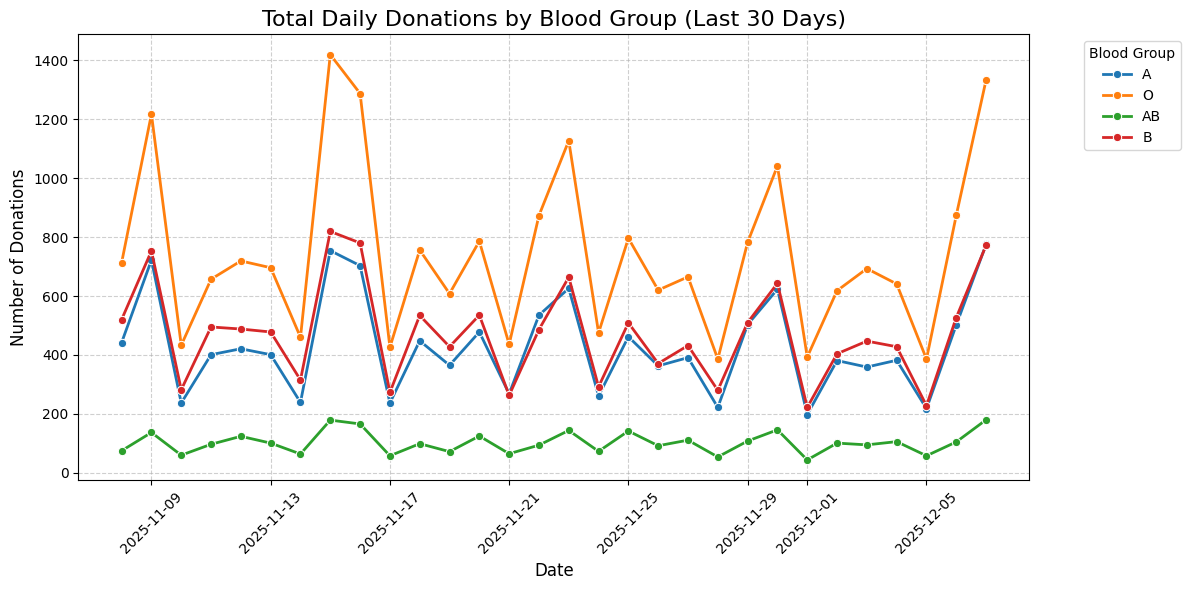

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

# 1. Get the latest date in the database to define "Last 30 Days"
latest_date_query = con.execute("SELECT MAX(visit_date) FROM historical").fetchone()
max_date = pd.to_datetime(latest_date_query[0])
start_date = max_date - timedelta(days=29) # 29 days back + today = 30 days window

print(f"Generating graph for period: {start_date.date()} to {max_date.date()}")

# 2. Extract daily counts per blood group for this window

df = pd.read_sql(f"""
    SELECT 
        visit_date, 
        blood_group, 
        COUNT(*) as total_donations
    FROM historical
    WHERE visit_date >= '{start_date.strftime('%Y-%m-%d')}'
      AND visit_date <= '{max_date.strftime('%Y-%m-%d')}'
      and blood_group not in ('N','U')
    GROUP BY visit_date, blood_group
    ORDER BY visit_date
""", con)

# Ensure visit_date is datetime for proper plotting
df['visit_date'] = pd.to_datetime(df['visit_date'])

# 3. Plotting
plt.figure(figsize=(12, 6))

# Using seaborn for easier multi-line plotting
sns.lineplot(
    data=df, 
    x='visit_date', 
    y='total_donations', 
    hue='blood_group', 
    marker='o',
    palette='tab10', # distinct colors
    linewidth=2
)

plt.title(f'Total Daily Donations by Blood Group (Last 30 Days)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Donations', fontsize=12)
plt.legend(title='Blood Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [5]:
con.close()